In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
#loading data
df = pd.read_csv("student_performance.csv")

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [29]:
df.shape

(1000, 8)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [31]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [32]:
#column cleaning

df.columns = df.columns.str.lower().str.replace(" ", "_")
df.columns

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

In [33]:
#missing values check

df.isnull().sum()

gender                         0
race/ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [34]:
#handling missing values

df = df.dropna()

In [35]:
#duplicate check

df.duplicated().sum()

np.int64(0)

In [36]:
df = df.drop_duplicates()

In [37]:
#data types check
df.dtypes

gender                         object
race/ethnicity                 object
parental_level_of_education    object
lunch                          object
test_preparation_course        object
math_score                      int64
reading_score                   int64
writing_score                   int64
dtype: object

In [38]:
#basic statistical summary
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


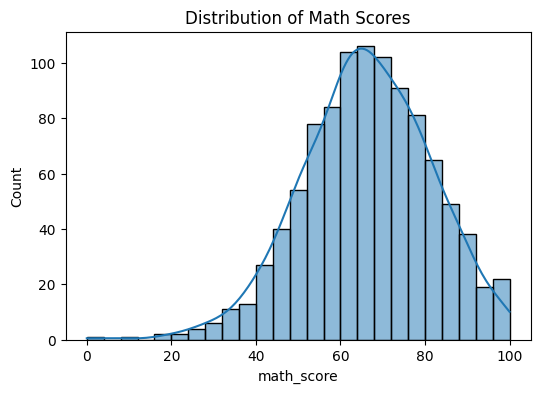

In [39]:
##UNIVARIATE ANALYSIS


#Math score distribution
plt.figure(figsize=(6,4))
sns.histplot(df["math_score"], kde=True)
plt.title("Distribution of Math Scores")
plt.show()

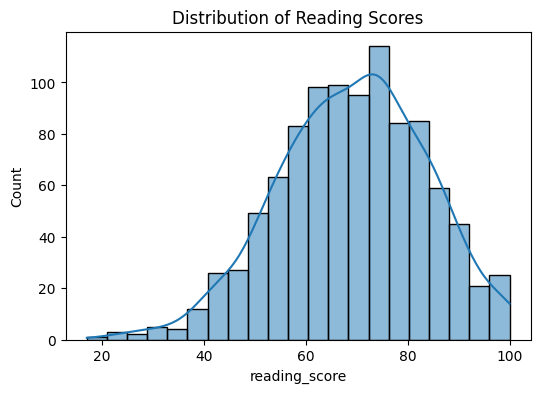

In [40]:
#reading score distribution
plt.figure(figsize=(6,4))
sns.histplot(df["reading_score"], kde=True)
plt.title("Distribution of Reading Scores")
plt.show()

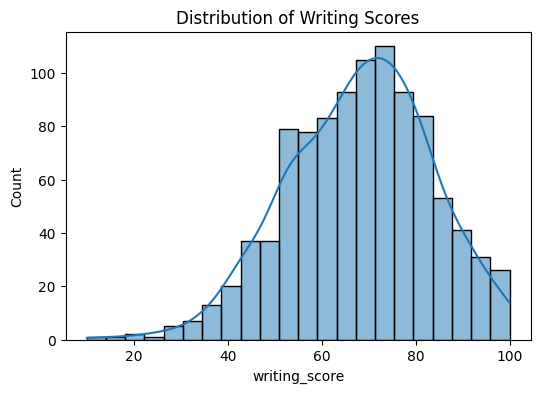

In [41]:
#writing score distribution
plt.figure(figsize=(6,4))
sns.histplot(df["writing_score"], kde=True)
plt.title("Distribution of Writing Scores")
plt.show()

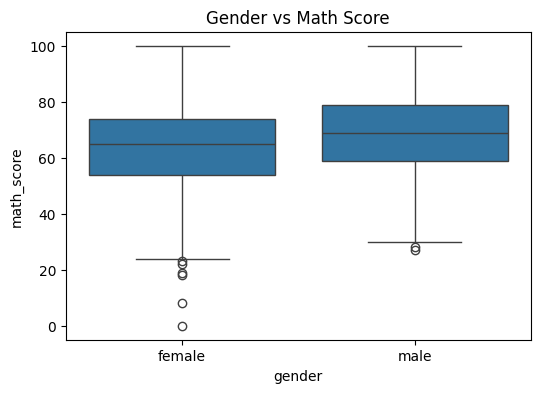

In [42]:
##gender vs performance

plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="math_score", data=df)
plt.title("Gender vs Math Score")
plt.show()

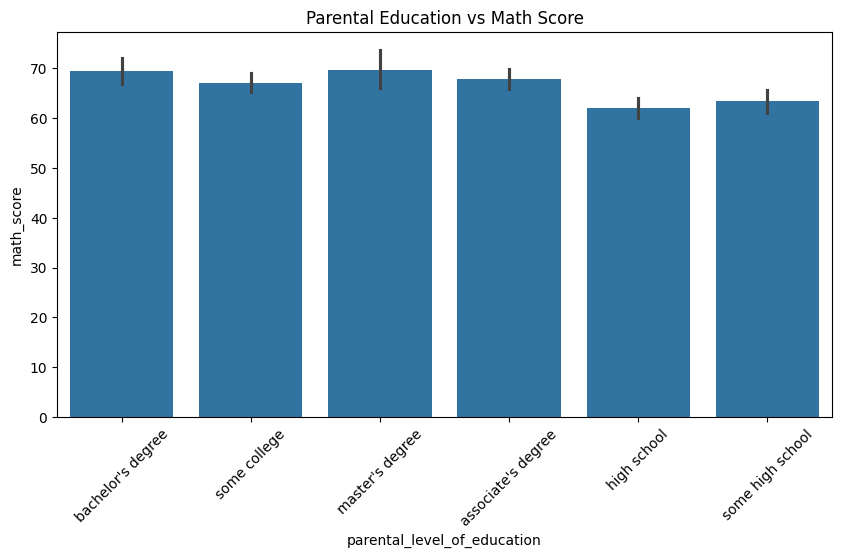

In [43]:
# PARENTAL EDUCATION VS SCORE

plt.figure(figsize=(10,5))
sns.barplot(x="parental_level_of_education", y="math_score", data=df)
plt.xticks(rotation=45)
plt.title("Parental Education vs Math Score")
plt.show()

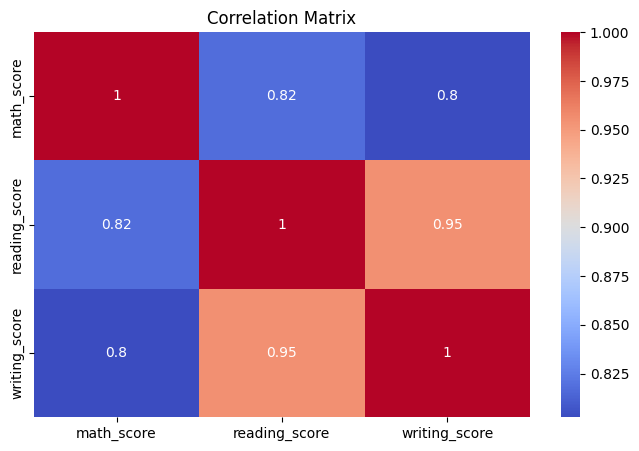

In [44]:
#correlation heatmap

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [45]:
#group analysis
df.groupby("gender")[["math_score", "reading_score", "writing_score"]].mean()

,math_score,reading_score,writing_score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


## Key Insights

- Female students often perform better in reading and writing
- Math scores vary more compared to other subjects
- Parental education has impact on student performance
- Scores are moderately correlated across subjects


In [46]:
##saving clean data

df.to_csv("../cleaned_student_data.csv", index=False)